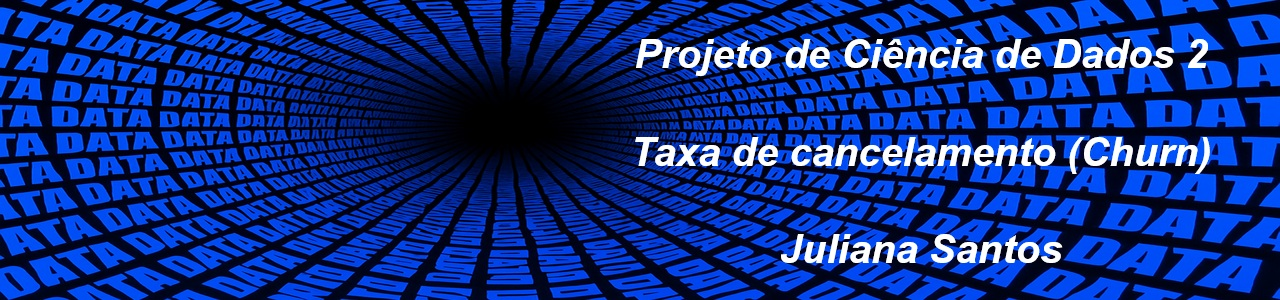

In [1]:
from IPython.display import Image
# Exibe a imagem
Image(filename='Imagem_Projeto_Ciencia_Dados_2.jpg')

# Análise de Classificação: Saídas de clientes (Churn)

## 📘 Introdução

Neste notebook, realizaremos uma análise preditiva utilizando o conjunto de dados Telco Customer Churn, disponível no Kaggle. O objetivo principal é identificar os fatores que influenciam o cancelamento de clientes (churn) e construir um modelo capaz de prever quais clientes estão propensos a deixar a empresa. Essa é uma aplicação onde buscamos entender padrões nos dados e gerar insights acionáveis para retenção de clientes.

## 📊 Dicionário de Dados
O conjunto de dados contém informações sobre clientes de uma empresa de telecomunicações, incluindo:

* **CustomerID**: Identificador único do cliente
* **Gender**: Gênero do cliente
* **SeniorCitizen**: Indica se o cliente é idoso (1) ou não (0)
* **Partner**: Cliente tem parceiro(a)?
* **Dependents**: Cliente tem dependentes?
* **Tenure**: Tempo de contrato em meses
* **PhoneService**: Cliente possui serviço de telefone?
* **MultipleLines**: Possui múltiplas linhas telefônicas?
* **InternetService**: Tipo de serviço de internet (DSL, Fiber optic, None)
* **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport**: Serviços adicionais
* **StreamingTV, StreamingMovies**: Serviços de streaming
* **Contract**: Tipo de contrato (Mensal, Anual, Bienal)
* **PaperlessBilling**: Fatura digital
* **PaymentMethod**: Método de pagamento
* **MonthlyCharges**: Valor mensal cobrado
* **TotalCharges**: Valor total cobrado
* **Churn**: Variável alvo — indica se o cliente cancelou o serviço. Se (1) cancelou

##💡 Importância da Análise
A previsão de churn é essencial para empresas de telecomunicações, pois:

* Reduz custos com aquisição de novos clientes
* Aumenta a fidelização e receita recorrente
* Permite ações proativas de retenção
* Melhora a experiência do cliente com ofertas personalizadas

Com essa análise, a empresa poderá identificar perfis de clientes com maior risco de cancelamento e agir preventivamente para mantê-los.

## 🧪 Metodologia
Utilizaremos algoritmos de classificação como Regressão Logística, Árvores de Decisão, Random Forest. O processo incluirá:

* Tratamento de dados ausentes e inconsistentes
* Codificação de variáveis categóricas
* Normalização de variáveis numéricas
* Divisão dos dados em treino e teste
* Avaliação dos modelos com métricas como accuracy, precision, recall e F1-score
* Interpretação dos resultados e geração de insights


Kaggle:  https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Sumário

1. Carregamento e Visualização dos Dados
2. Limpeza dos Dados
3. Análise Exploratória dos Dados (EDA)
4. Pré-processamento e engenharia de atributos (Feature Engineering)
5. Treinamento e Avaliação de Modelos
6. Comparação de Modelos
7. Ajuste de Hiperparâmetros
8. Conclusão

# 1. Carregamento e Visualização dos Dados

Visão inicial do dataset: tamanho, tipos de variáveis, valores nulos e como está a distribuição do Churn.

In [2]:
# importar bibliotecas necessárias para o projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning
from pandas.plotting import scatter_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# Carregar os dados
try:
  df = pd.read_csv("Telco-Customer-Churn.csv")
except FileNotFoundError:
    print("Arquivo não encontrado. Por favor, verifique o caminho do arquivo.")

In [4]:
# Visualizar as primeiras linhas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Visualizar as últimas linhas
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# Verificar informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Dimensão do dataset
df.shape

(7043, 21)

In [8]:
# Estatísticas descritivas (apenas das variáveis numéricas)
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Soma dos valores ausentes
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
# Verificação de Duplicatas
df.duplicated().sum()

np.int64(0)

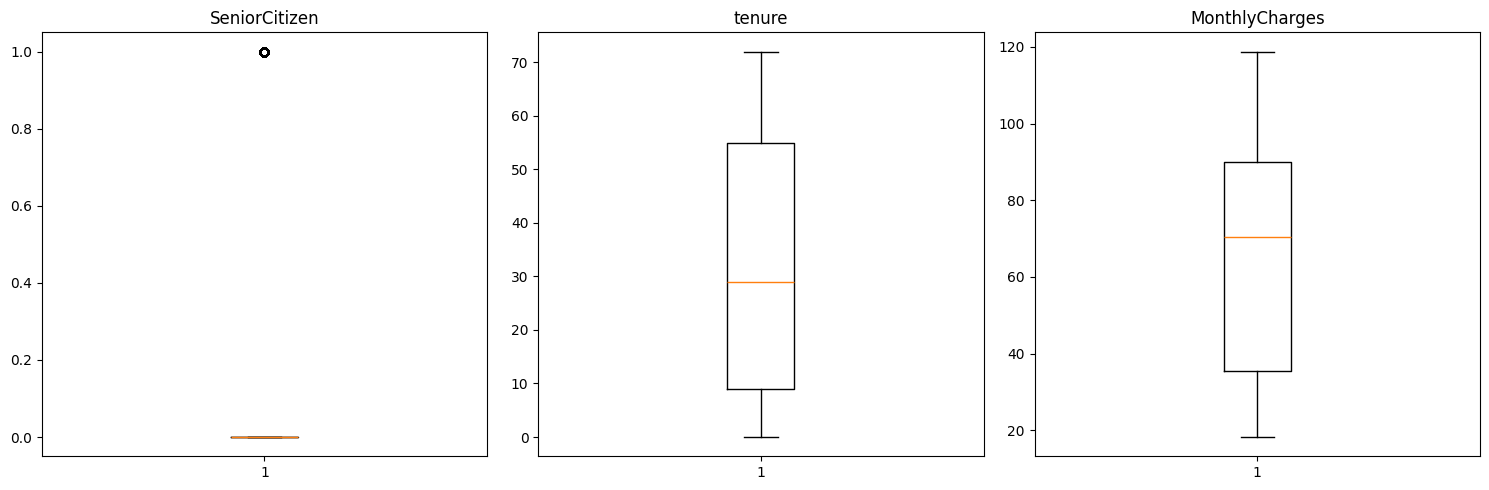

In [11]:
# Verificação de Outliers
# Verificamos outliers usando boxplots (apenas das colunas númericas)

# Selecionar apenas colunas numéricas
numeric_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    plt.boxplot(df[col].dropna())  # Não esquecer de remover valores ausentes caso existam
    plt.title(col)

plt.tight_layout()
plt.show()

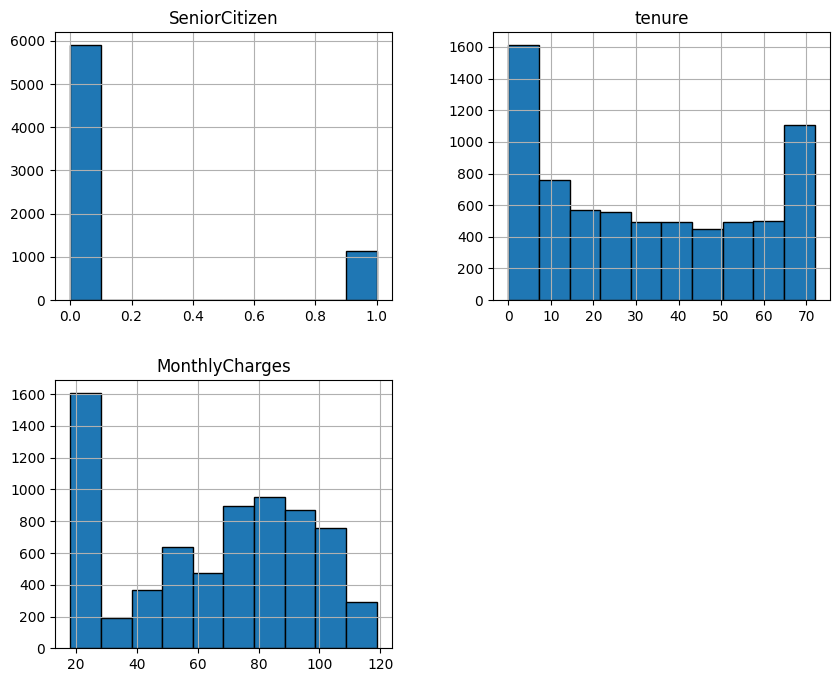

In [12]:
# Distribuição das variáveis do dataset

# Para variáveis binárias, usamos gráficos de contagem.
df.hist(figsize=(10, 8), bins=10, edgecolor="black")
plt.show()

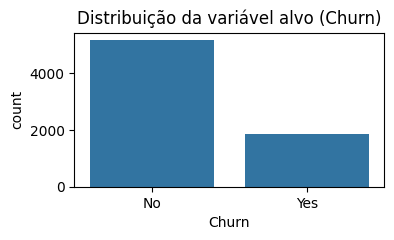

In [13]:
# Distribuição da variável alvo (Churn)
plt.figure(figsize=(4, 2)) # redefinir o tamanho da figura para não ficar muito grande
sns.countplot(x="Churn", data=df)
plt.title("Distribuição da variável alvo (Churn)")
plt.show()

# 2. Limpeza dos Dados

Preparar o dataset para análise e modelagem, garantindo que os dados estejam consistentes, completos e com tipos corretos.

In [14]:
# Verificar espaços em branco, visto que eles podem atrapalhar na contagem dos dados nulos.
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

In [15]:
# ajustar os tipos das variáveis
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService',
                       'MultipleLines', 'InternetService', 'OnlineSecurity',
                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract',
                       'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Churn']

# Converter para tipo 'category'
for col in categorical_columns:
    df[col] = df[col].astype('category')

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [16]:
# verificando se as colunas esão do tipo certo
df.dtypes

,0
customerID,object
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category
OnlineSecurity,category


In [17]:
# Verificar se depois da limpeza e tranformção há valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

Valores ausentes por coluna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


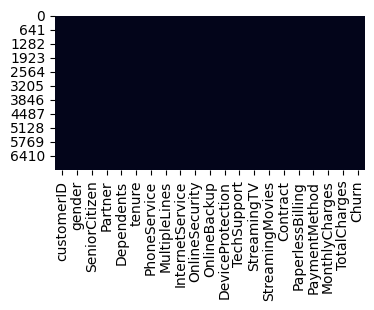

In [18]:
# Gráfico rápido para ver os nulos encontrados. Como são apenas 11 as linhas em branco não aparecem na coluna do "TotalCharges"
plt.figure(figsize=(4, 2))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [19]:
# Filtrar linhas com valores ausentes em 'TotalCharges'
missing_total_charges = df[df['TotalCharges'].isna()]

# Exibir essas linhas - Apenas para conferencia e confirmação.
print(missing_total_charges)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0       1          1       0   
753   3115-CZMZD    Male              0       0          1       0   
936   5709-LVOEQ  Female              0       1          1       0   
1082  4367-NUYAO    Male              0       1          1       0   
1340  1371-DWPAZ  Female              0       1          1       0   
3331  7644-OMVMY    Male              0       1          1       0   
3826  3213-VVOLG    Male              0       1          1       0   
4380  2520-SGTTA  Female              0       1          1       0   
5218  2923-ARZLG    Male              0       1          1       0   
6670  4075-WKNIU  Female              0       1          1       0   
6754  2775-SEFEE    Male              0       0          1       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488             0  No phone service             DSL                  Yes  ... 

In [20]:
# Exclui "totalCharges" que estão NAN pq a várivel que seria possível usar para fazer o cálculo e completar/preencher a coluna estão zeradas ("tenure")

# Remover linhas com valores ausentes
df_cleaned = df.dropna()

In [21]:
# Verificar novamente se ainda existem valores ausentes
print("Valores ausentes por coluna:")
print(df_cleaned.isnull().sum())

Valores ausentes por coluna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [22]:
# Salvar dataset limpo
# df_cleaned.to_csv('Telco-Customer-Churn-Clean.csv', index=False)

# 3. Análise Exploratória dos Dados (EAD)

Entender padrões nos dados, identificar relações entre variáveis e a variável alvo Churn.

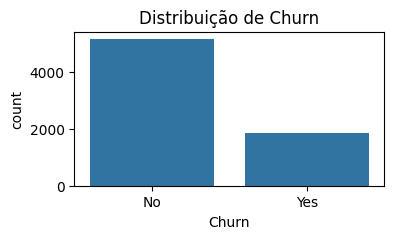

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [23]:
# Distribuição de churn
plt.figure(figsize=(4, 2))
sns.countplot(x='Churn', data=df_cleaned)
plt.title('Distribuição de Churn')
plt.show()

# Porcentagem
print(df_cleaned['Churn'].value_counts(normalize=True)*100)

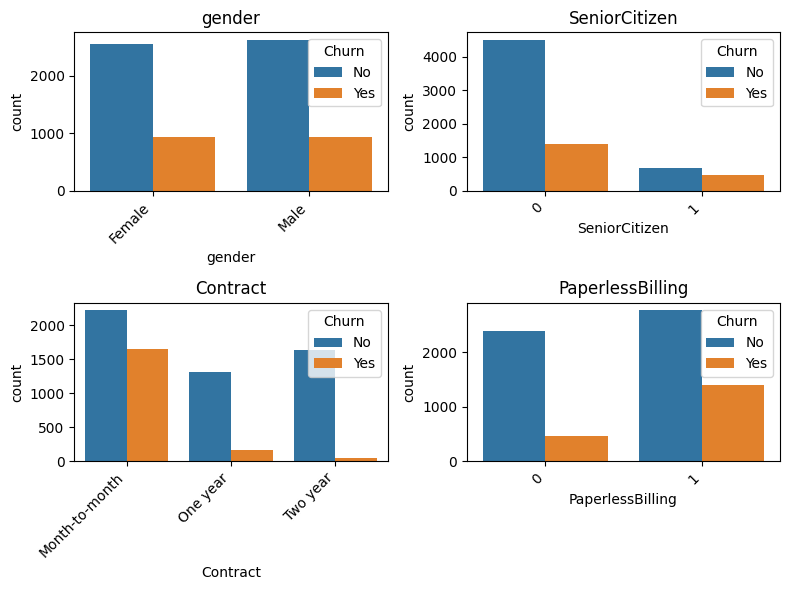

In [24]:
# colunas que serão analisadas nestes gráficos
colunas = ['gender','SeniorCitizen','Contract','PaperlessBilling']

# Define o tamanho da grade (linhas x colunas)
n_rows = 2
n_cols = 2

plt.figure(figsize=(n_cols*4, n_rows*3))  # Ajustar o tamanho da figura

for i, service in enumerate(colunas):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(x=service, hue='Churn', data=df_cleaned)
    plt.title(service)
    plt.xticks(rotation=45, ha='right')  # Rotaciona labels se precisar e quanto de rotação
    plt.tight_layout()  # Ajusta para não sobrepor

plt.show()

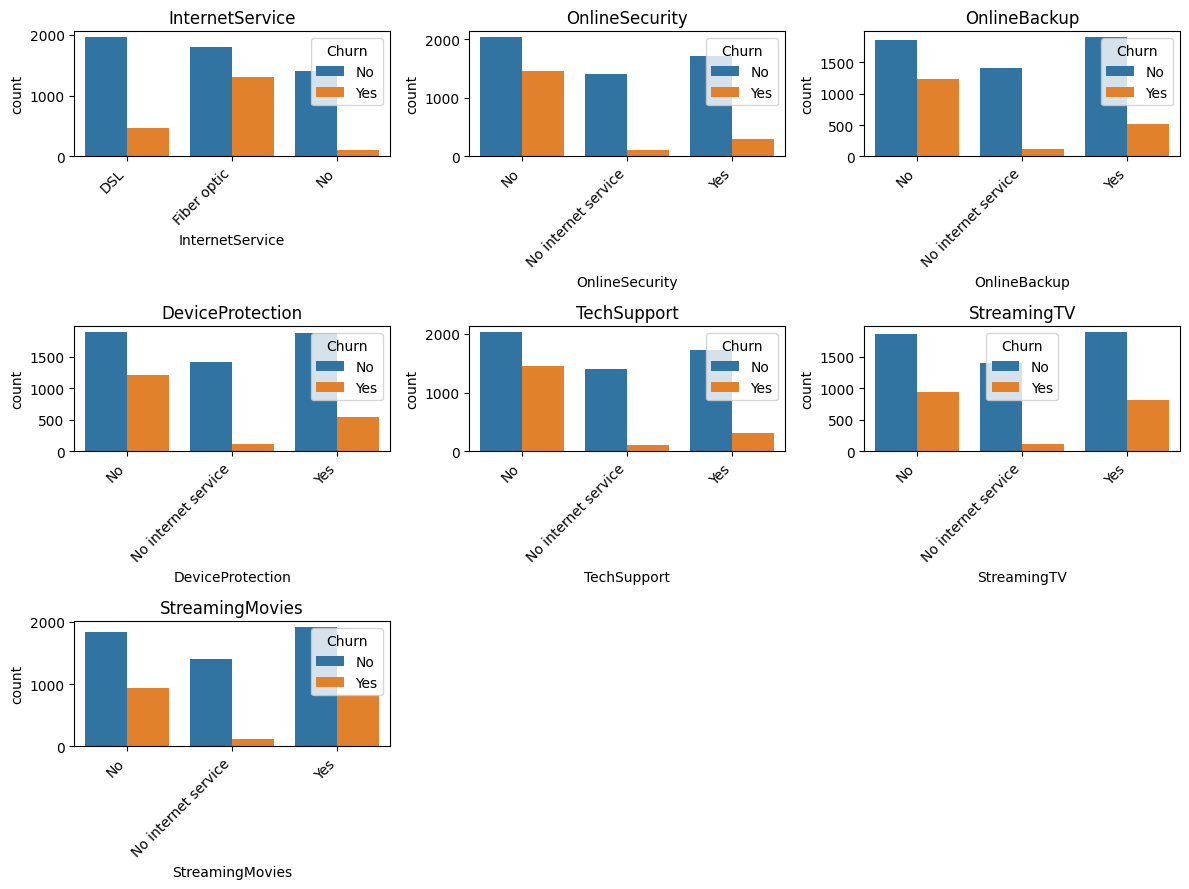

In [25]:
# Serviços de internet que serão analisados nos próximos gráficos
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Define o tamanho da grade (linhas x colunas)
n_rows = 3
n_cols = 3

plt.figure(figsize=(n_cols*4, n_rows*3))  # Ajustar o tamanho da figura

for i, service in enumerate(services):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(x=service, hue='Churn', data=df_cleaned)
    plt.title(service)
    plt.xticks(rotation=45, ha='right') # Rotaciona labels se precisar e quanto de rotação
    plt.tight_layout()  # Ajusta para não sobrepor

plt.show()

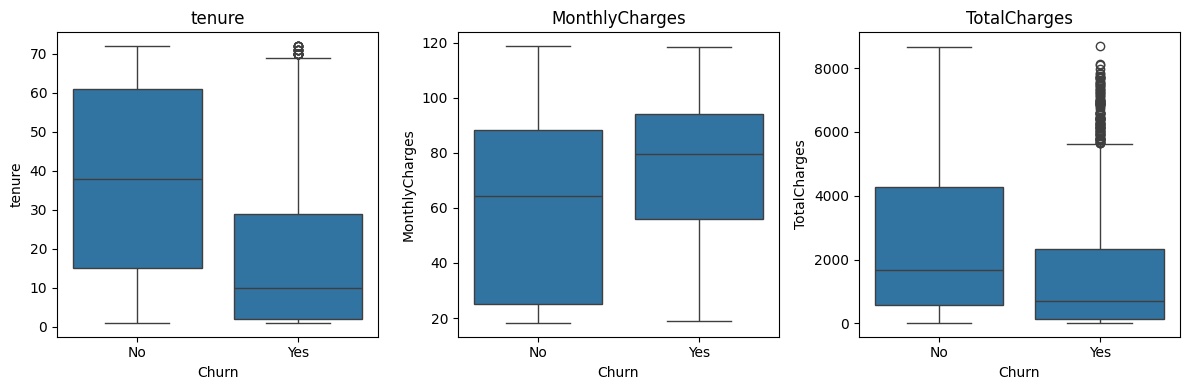

In [26]:
# Colunas que serão analisadas
numeric_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Boxplots por churn
plt.figure(figsize=(12,4))  # Uma linha, três colunas
for i, col in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i+1)
    sns.boxplot(x='Churn', y=col, data=df_cleaned)
    plt.title(col)

plt.tight_layout()
plt.show()

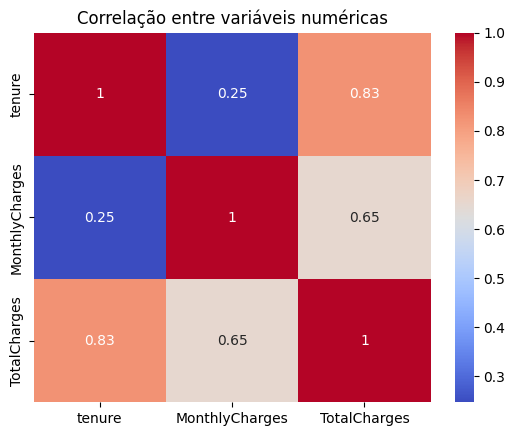

In [27]:
# heatmap (apenas variáveis numéricas)
corr = df_cleaned[numeric_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis numéricas')
plt.show()

# 4. Pré-processamento e engenharia de atributos (Feature Engineering)
Preparar os dados para os modelos de machine learning, convertendo variáveis categóricas, normalizando numéricas e criando novas features que possam melhorar a previsão de churn.


In [28]:
# Variáveis numéricas
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Variáveis categóricas
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']


In [29]:
# Excluir váriavel que não será necessária para a analise
df_cleaned.drop('customerID', axis=1, inplace=True)

/tmp/ipython-input-3415016859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.drop('customerID', axis=1, inplace=True)


In [30]:
df_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,No
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,No
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,Yes
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,Yes


In [31]:
# Porcentagem da coluna "Churn". Verificar se está balanceada
print(df_cleaned['Churn'].value_counts(normalize=True)*100)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [32]:
# Realizar balanceamento
# separar os churn 1 dos churn 0
df_no = df_cleaned[df_cleaned['Churn'] == 'No']
df_yes = df_cleaned[df_cleaned['Churn'] == 'Yes']

# Reduzindo a classe maior para o tamanho da menor
df_no_sampled = df_no.sample(len(df_yes), random_state=42)

# Combina os dois
df_balanced = pd.concat([df_no_sampled, df_yes]).reset_index(drop=True)

Churn
No     1869
Yes    1869
Name: count, dtype: int64
Churn
No     50.0
Yes    50.0
Name: proportion, dtype: float64


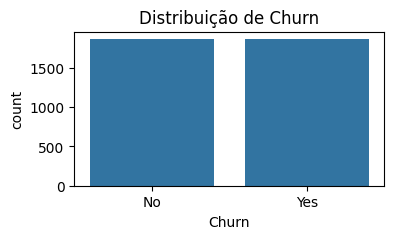

Churn
No     50.0
Yes    50.0
Name: proportion, dtype: float64


In [33]:
# Distribuição de churn depois do balanceamento

# Contagem absoluta
print(df_balanced['Churn'].value_counts())

# Proporção em %
print(df_balanced['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(4, 2))
sns.countplot(x='Churn', data=df_balanced)
plt.title('Distribuição de Churn')
plt.show()

# Porcentagem
print(df_balanced['Churn'].value_counts(normalize=True)*100)

In [34]:
#  Verificar dados depois do balanceamento
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3738 entries, 0 to 3737
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            3738 non-null   category
 1   SeniorCitizen     3738 non-null   int64   
 2   Partner           3738 non-null   category
 3   Dependents        3738 non-null   category
 4   tenure            3738 non-null   int64   
 5   PhoneService      3738 non-null   category
 6   MultipleLines     3738 non-null   category
 7   InternetService   3738 non-null   category
 8   OnlineSecurity    3738 non-null   category
 9   OnlineBackup      3738 non-null   category
 10  DeviceProtection  3738 non-null   category
 11  TechSupport       3738 non-null   category
 12  StreamingTV       3738 non-null   category
 13  StreamingMovies   3738 non-null   category
 14  Contract          3738 non-null   category
 15  PaperlessBilling  3738 non-null   category
 16  PaymentMethod     3738 n

In [35]:
warnings.filterwarnings('ignore', category=SettingWithCopyWarning)

# Variáveis binárias: mapear 'Yes'/'No' para 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# for col in binary_cols:
#     df_balanced[col] = df_balanced[col].map({'Yes':1, 'No':0}) # Essa linha de comando gerou problema, apagou registros mais a frente.

# One-Hot Encoding para as demais categóricas
# drop_first=True vai evitar multicolinearidade ao criar dummies.
df_balanced = pd.get_dummies(df_balanced, columns=[col for col in categorical_cols if col not in binary_cols + ['SeniorCitizen']], drop_first=True)

# Churn deve ser int para evitar problemas ao tentar fazer a correlação
df_balanced['Churn'] = df_balanced['Churn'].map({'Yes':1, 'No':0}).astype(int)

In [36]:
# nomes das colunas depois do one-hot encoding
print(df_balanced.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [37]:
#Normalização de variáveis numéricas
scaler = StandardScaler()
df_balanced[numeric_cols] = scaler.fit_transform(df_balanced[numeric_cols])

In [38]:
# Selecionar apenas colunas numéricas
numeric_cols = df_balanced.select_dtypes(include=['int64', 'float64']).columns

# calcular a correlação de Pearson com o churn:
df_corr = df_balanced[numeric_cols].corr()['Churn'].sort_values(ascending=False)
print(df_corr)

Churn             1.000000
MonthlyCharges    0.227567
SeniorCitizen     0.146062
TotalCharges     -0.230800
tenure           -0.400785
Name: Churn, dtype: float64


In [39]:
# Criar váriaveis adicionais para apronfundar a analise

# Tempo médio de gasto por mês
df_balanced['AvgCharges'] = df_balanced['TotalCharges'] / (df_balanced['tenure'] + 1e-5)

# Cliente com múltiplos serviços de streaming
df_balanced['StreamingServices'] = df_balanced[['StreamingTV_Yes', 'StreamingMovies_Yes']].sum(axis=1)

# Cliente com muitos serviços adicionais
extra_services = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'TechSupport_Yes']
df_balanced['ExtraServices'] = df_balanced[extra_services].sum(axis=1)

# Cliente "recente" ou "velho" (tenure baixo x alto)
df_balanced['RecentCustomer'] = (df_balanced['tenure'] < 12).astype(int)

# Relação entre cobrança mensal e total
df_balanced['ChargeRatio'] = df_balanced['MonthlyCharges'] / (df_balanced['TotalCharges'] + 1e-5)

# Serviços combinados
df_balanced['SecurityServices'] = df_balanced[['OnlineSecurity_Yes', 'TechSupport_Yes']].sum(axis=1)
df_balanced['BackupServices'] = df_balanced[['OnlineBackup_Yes', 'DeviceProtection_Yes']].sum(axis=1)

# Seleciona colunas que indicam que o serviço está ativo
service_cols = [col for col in df_balanced.columns if col.endswith('_Yes') or col == 'PhoneService']

# Criar coluna TotalServices somando apenas serviços ativos
df_balanced['TotalServices'] = df_balanced[service_cols].sum(axis=1)


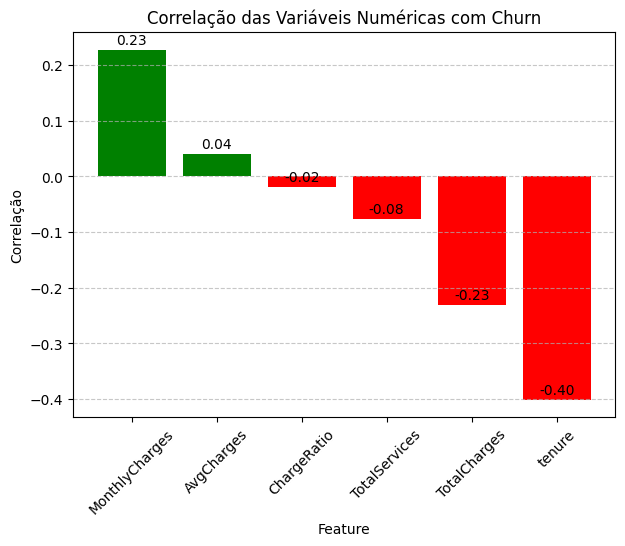

In [40]:
# criar corelação entre as variaveis númericas e o "Churn"
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges', 'ChargeRatio', 'TotalServices']

# Garantir que as colunas sejam numéricas
df_corr_numeric = df_balanced[numeric_cols + ['Churn']].apply(pd.to_numeric, errors='coerce')

# Calcular correlação da variável alvo 'Churn' com as numéricas
corr_with_churn = df_corr_numeric.corr().loc[:, 'Churn']  # garante Series

# Remover a própria coluna Churn da correlação
corr_with_churn = corr_with_churn.drop('Churn').sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(7,5))
colors = ['green' if v > 0 else 'red' for v in corr_with_churn]
bars = plt.bar(corr_with_churn.index, corr_with_churn, color=colors)

# Adicionar valores acima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=10)

plt.title("Correlação das Variáveis Numéricas com Churn")
plt.ylabel("Correlação")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 900x900 with 0 Axes>

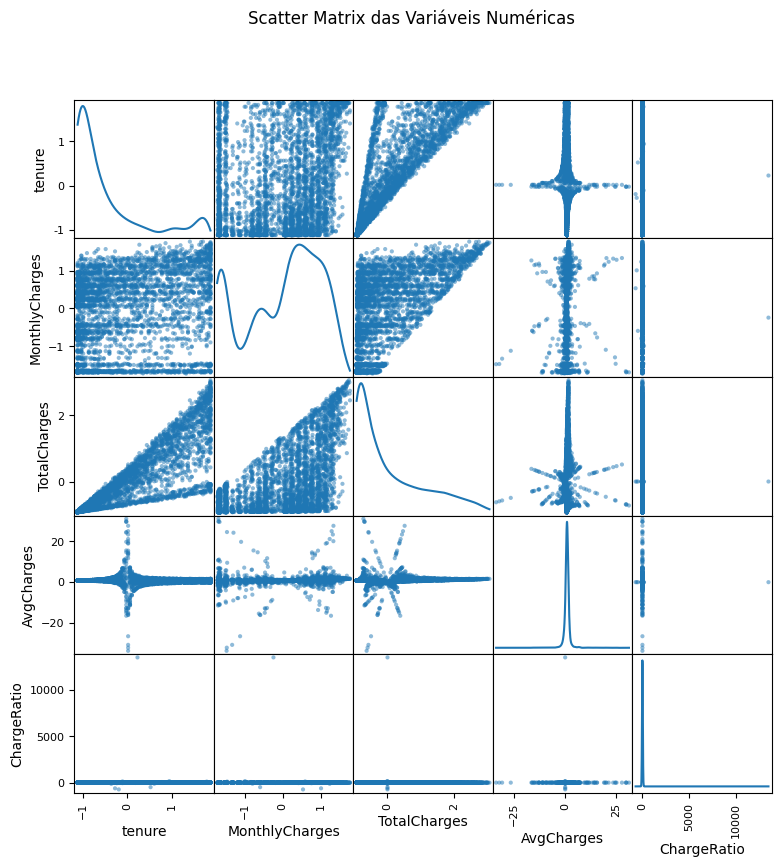

In [41]:
# Selecionar colunas numéricas importantes
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharges', 'ChargeRatio', 'TotalServices']

# Scatter matrix (gráfico de dispersão entre todas essas variáveis)
plt.figure(figsize=(9,9))
scatter_matrix(df_balanced[numeric_cols], alpha=0.5, figsize=(9,9), diagonal='kde')
plt.suptitle("Scatter Matrix das Variáveis Numéricas")
plt.show()

In [42]:
# checando se alguma coluna do DataFrame só tem um valor único, senão será eliminada porque não agregam informação.
for col in df_balanced.columns:
    nunique = df_balanced[col].nunique()
    if nunique <= 1:
        print(f"{col} tem {nunique} valor(es) único(s)")

RecentCustomer tem 1 valor(es) único(s)


In [43]:
# ***********************************************************************
# # Lista de features derivadas que podem ser removidas para reduzir colinearidade.
# #Essas colunas reduntantes podem atrapalhar a Regressão Logistica. Por isso é melhor excluí-las
# # Deixei o VIF > 10 excluir mais a frente no código, pois não sei porque o modelo de regressão logisitica repondeu melhor do que eu excluir manualmente todas essas abaixo.
# Deixei aqui para lembrar e pesquisar melhor depois
# ***********************************************************************


# cols_to_drop = ['StreamingServices', 'ExtraServices', 'SecurityServices', 'BackupServices', 'TotalServices', 'AvgCharges' ,'ChargeRatio', 'RecentCustomer']

# df_model = df_balanced.drop(columns=cols_to_drop)

In [44]:
# Separar features e target
X = df_balanced.drop('Churn', axis=1)
y = df_balanced['Churn']

In [45]:
# Divisão em treino e teste
# stratify=y garante que a proporção de churn seja mantida em treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
print(X_train.isna().sum().sum())

0


In [46]:
# Teste de colinearidade (VIF – Variance Inflation Factor) - Se duas variáveis forem muito parecidas, uma pode ser descartada.
# Calcular VIF

def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data.sort_values("VIF", ascending=False)

# Seleciona apenas variáveis numéricas
X_numeric = X_train.select_dtypes(include=['int64', 'float64']).copy()

# Converte booleanos para int, se existirem
bool_cols = X_numeric.select_dtypes(include=['bool']).columns
X_numeric[bool_cols] = X_numeric[bool_cols].astype(int)

vif_data = calculate_vif(X_numeric)
print(vif_data)


              feature        VIF
13   SecurityServices        inf
14     BackupServices        inf
10      ExtraServices        inf
11     RecentCustomer  32.218817
15      TotalServices  24.655909
7        TotalCharges  10.489023
3              tenure   7.096329
9   StreamingServices   6.275156
6      MonthlyCharges   5.158572
4        PhoneService   2.172409
1             Partner   1.452252
2          Dependents   1.363201
5    PaperlessBilling   1.162698
0       SeniorCitizen   1.132457
8          AvgCharges   1.031446
12        ChargeRatio   1.012780


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [47]:
# Se houvessem VIF maior que 10, serão ser removidos.

def remove_high_vif(df, threshold=10):
    while True:
        vif = calculate_vif(df)
        max_vif = vif['VIF'].max()
        if max_vif > threshold:
            drop_feature = vif.sort_values('VIF', ascending=False)['feature'].iloc[0]
            print(f"Removendo variável: {drop_feature} (VIF={max_vif:.2f})")
            df = df.drop(columns=[drop_feature])
        else:
            break
    return df

X_train = remove_high_vif(X_numeric)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Removendo variável: SecurityServices (VIF=inf)
Removendo variável: RecentCustomer (VIF=32.22)
Removendo variável: TotalServices (VIF=90.16)
Removendo variável: TotalCharges (VIF=10.38)


# 5. Treinamento e Avaliação de Modelos


In [48]:
# função generica para treinar e avaliar modelos
def train_evaluate_model(model, X_train, X_test, y_train, y_test):
    # Treinar
    model.fit(X_train, y_train)

    # Previsão
    y_pred = model.predict(X_test)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Modelo: {model.__class__.__name__}")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-"*50)

    return accuracy, precision, recall, f1

In [49]:
# modelos que serão avaliados nesse projeto
models = [
    LogisticRegression(max_iter=1000, random_state=42),
    DecisionTreeClassifier(random_state=42),
    RandomForestClassifier(n_estimators=100, random_state=42)
]

In [50]:
# Treinar e avaliar cada modelo escolhido
results = {}

for model in models:
    acc, prec, rec, f1 = train_evaluate_model(model, X_train, X_test, y_train, y_test)
    results[model.__class__.__name__] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

Modelo: LogisticRegression
Accuracy : 0.754
Precision: 0.7615
Recall   : 0.7398
F1-Score : 0.7505

Confusion Matrix:
[[431 130]
 [146 415]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       561
           1       0.76      0.74      0.75       561

    accuracy                           0.75      1122
   macro avg       0.75      0.75      0.75      1122
weighted avg       0.75      0.75      0.75      1122

--------------------------------------------------
Modelo: DecisionTreeClassifier
Accuracy : 0.672
Precision: 0.6784
Recall   : 0.6542
F1-Score : 0.6661

Confusion Matrix:
[[387 174]
 [194 367]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.69      0.68       561
           1       0.68      0.65      0.67       561

    accuracy                           0.67      1122
   macro avg       0.67      0.67      0.67      1122
weighted avg      

# 6. Comparação de Modelos


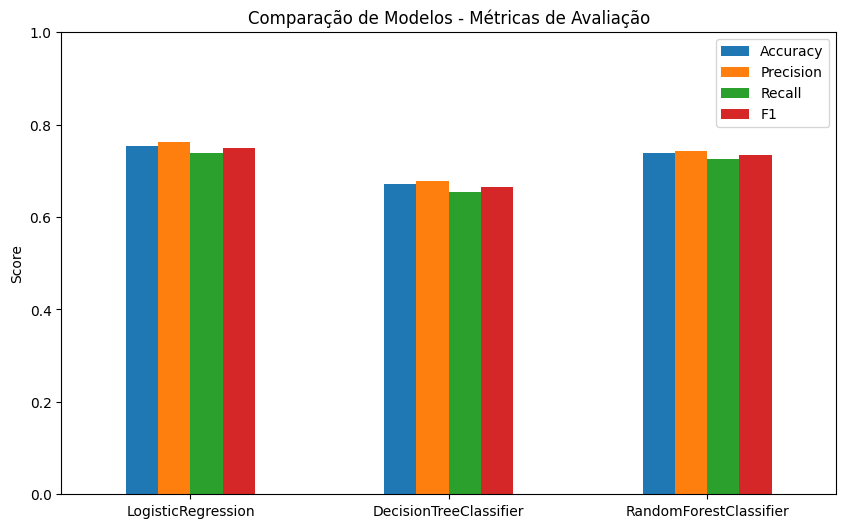

In [51]:
# Este gráfico mostra os resultados dos 3 modelos que foram testados

# Transformar resultados em DataFrame
results_df = pd.DataFrame(results).T

# Plotar gráfico comparativo
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Comparação de Modelos - Métricas de Avaliação")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

# 7. Ajuste de Hiperparâmetros


In [52]:
# Modelo que se saiu melhor
# Vamos tentar melhora-lo alterando os hiperparametros
log_reg = LogisticRegression(random_state=42)

# Grade de hiperparâmetros
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [500, 1000]
}

# Ajuste com validação cruzada
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # ou 'accuracy', depende do que for otimizar
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor score:", grid_search.best_score_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Melhores parâmetros: {'C': 0.1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Melhor score: 0.7517636413694889


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
100 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solv

In [53]:
# modelo otimizado para a regressão logistica
# Criar modelo com os melhores hiperparâmetros
best_log_reg = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='liblinear',
    max_iter=500,
    random_state=42
)

# Treinar no conjunto de treino
best_log_reg.fit(X_train, y_train)

# Prever no conjunto de teste
y_pred_best = best_log_reg.predict(X_test)

In [54]:
accuracy  = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall    = recall_score(y_test, y_pred_best)
f1        = f1_score(y_test, y_pred_best)

print(f"Modelo: {best_log_reg.__class__.__name__} (Parâmetros Ajustado)")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))
print("-"*50)

Modelo: LogisticRegression (Parâmetros Ajustado)
Accuracy : 0.7567
Precision: 0.7657
Recall   : 0.7398
F1-Score : 0.7525

Confusion Matrix:
[[434 127]
 [146 415]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       561
           1       0.77      0.74      0.75       561

    accuracy                           0.76      1122
   macro avg       0.76      0.76      0.76      1122
weighted avg       0.76      0.76      0.76      1122

--------------------------------------------------


# 8. Conclusão — Projeto Telco Customer Churn

O objetivo foi analisar e prever o **churn** dos clientes da Telco usando **Regressão Logística, Árvore de Decisão e Random Forest**.

## 🔹 Insights Principais da Análise Exploratória
- Dataset balanceado: **50% clientes ativos / 50% cancelados**.  
- **Contratos mensais:** 52,4%, 1 ano: 23,3%, 2 anos: 24,3%.  
- **Cobrança média mensal:** R$ 65,60
- **Tempo médio de contrato:** 32 meses  
- Clientes **recentes** ou com **muitos serviços adicionais** têm maior risco de churn.

## 🔹 Desempenho dos Modelos

| Modelo                         | Accuracy | F1-Score | AUC  |
|--------------------------------|---------|----------|------|
| Regressão Logística (original) | 75,4%   | 75,1%    | -    |
| Regressão Logística (ajustada) | 75,7%   | 75,3%    | 0,85*|
| Random Forest                  | 73,8%   | 73,5%    | -    |
| Árvore de Decisão               | 67,2%   | 66,6%    | -    |

*AUC foi estimada separadamente

## 🔹 Insights de Previsão
- Clientes com **tenure** (Tempo de contrato em meses) **< 12 meses** → churn ≈ **68%**
- Clientes com **MonthlyCharges** (Valor mensal cobrado) **> R$85** → churn > **70%**
- Clientes com **mais de 48 meses** → churn < **25%**

## 🔹 Ações Recomendadas
- Focar em **retenção de clientes recentes**  
- Oferecer **pacotes personalizados** para clientes com **alta cobrança mensal**  
- Monitorar **clientes com múltiplos serviços adicionais** para prevenir cancelamentos


**Conclusão:**  
A **Regressão Logística ajustada** é o modelo mais eficaz, permitindo ações preventivas de fidelização, redução de churn e aumento de receita recorrente.


# ***************************************************************************
# Abaixo: Analisando as informações dessa base de dados mais a fundo usando o modelo ajustado.
# ***************************************************************************

In [55]:
# Percentual de clientes com contrato de 1 ano
pct_1_year = (df_balanced['Contract_One year'].mean() * 100).round(2)
# Percentual de clientes com contrato de 1 ano
pct_2_year = (df_balanced['Contract_Two year'].mean() * 100).round(2)
print(f"Percentual de clientes com contrato de 1 ano: {pct_1_year}%")

print(f"Percentual de clientes com contrato de 2 anos: {pct_2_year}%")

Percentual de clientes com contrato de 1 ano: 17.09%
Percentual de clientes com contrato de 2 anos: 16.88%


In [56]:
# calculando a porcentagem de clientes que possuem certos serviços ativos
service_cols = ['StreamingTV_Yes', 'StreamingMovies_Yes', 'OnlineSecurity_Yes']
for col in service_cols:
    pct = df_balanced[col].mean() * 100
    print(f"{col}: {pct:.2f}%")

StreamingTV_Yes: 39.83%
StreamingMovies_Yes: 39.94%
OnlineSecurity_Yes: 24.69%


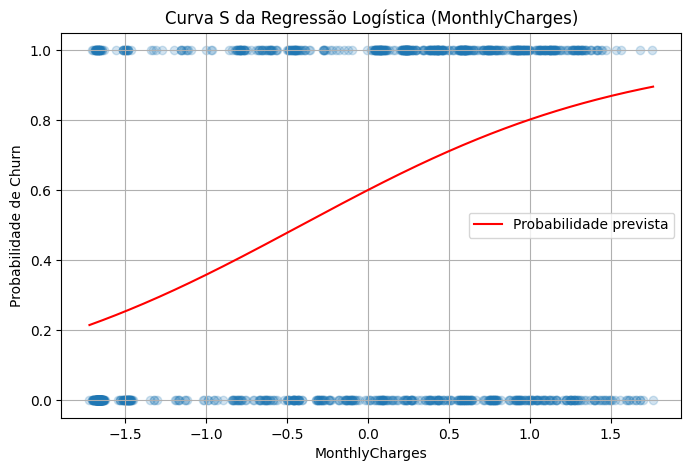

In [57]:
# Criar uma linha base com as médias (somente numéricas)
X_mean = X_test.copy()

# Pega as médias só de colunas numéricas
numeric_means = X_mean.select_dtypes(include=[np.number]).mean()

# Cria DataFrame repetido 300x com valores médios
X_curve = pd.DataFrame([numeric_means.values] * 300, columns=numeric_means.index)

# Reinsere as colunas categóricas (fixas como 0, se forem dummies)
for col in X_test.columns:
    if col not in X_curve.columns:
        X_curve[col] = 0  # mantém fixo

# Varia apenas MonthlyCharges
X_curve['MonthlyCharges'] = np.linspace(X_test['MonthlyCharges'].min(),
                                        X_test['MonthlyCharges'].max(), 300)

# Previsão
y_prob = best_log_reg.predict_proba(X_curve[X_test.columns])[:, 1]

# Plot
plt.figure(figsize=(8,5))
plt.plot(X_curve['MonthlyCharges'], y_prob, color='red', label='Probabilidade prevista')
plt.scatter(X_test['MonthlyCharges'], y_test, alpha=0.2)
plt.xlabel('MonthlyCharges')
plt.ylabel('Probabilidade de Churn')
plt.title('Curva S da Regressão Logística (MonthlyCharges)')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# atributos do treinou do modelo
features_train = X_train.columns

# Garantir que o teste tenha as mesmas colunas que o treino
X_test_aligned = X_test.reindex(columns=features_train, fill_value=0)

# Previsões
y_pred = best_log_reg.predict(X_test_aligned)
y_prob = best_log_reg.predict_proba(X_test_aligned)[:,1]

# DataFrame com resultados
results_df = X_test.copy()
results_df['Churn_Previsto'] = y_pred
results_df['Prob_Churn (%)'] = (y_prob * 100).round(2)

# Churn_Previsto e Prob_Churn (%) ficar mais a frente na tabela
cols = ['Churn_Previsto', 'Prob_Churn (%)'] + [col for col in X_test.columns if col not in ['Churn_Previsto', 'Prob_Churn (%)']]

# Reorganizar o DataFrame
results_df = results_df[cols]

results_df.head()

,Churn_Previsto,Prob_Churn (%),SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,AvgCharges,StreamingServices,ExtraServices,ChargeRatio,BackupServices
1720,0,6.76,0,0,0,1.608818,1,1,-0.234158,0.566714,0,3,-0.256822,2
632,0,12.11,0,1,1,0.353361,1,0,-0.494700,-0.123002,0,2,11.384053,1
295,0,27.59,0,0,0,1.399575,1,0,1.254400,1.421920,2,2,0.630317,1
1780,0,24.20,0,0,0,0.646301,1,1,0.790637,1.314572,0,4,0.930562,2
3374,1,84.23,1,0,0,-0.902095,1,1,0.599573,0.779768,1,1,-0.852385,0


In [59]:
# Mostrar 5 primeiras previsões de probabilidade apenas com os clientes e o churn
pd.DataFrame({'Cliente': X_test.index, 'Prob_Churn': y_prob, 'Prev_Churn': y_pred}).head()

,Cliente,Prob_Churn,Prev_Churn
0,1720,0.067648,0
1,632,0.121110,0
2,295,0.275926,0
3,1780,0.242036,0
4,3374,0.842316,1


In [60]:
df_display = pd.DataFrame({
    'Cliente': X_test.index,
    'Prob_Churn': y_prob * 100,  # multiplicando por 100 se quiser %
    'Prev_Churn': y_pred,
    'tenure': X_test['tenure'],
    'MonthlyCharges': X_test['MonthlyCharges']
})

for idx, row in df_display.head().iterrows():
    print(f"Cliente {row['Cliente']}:")
    print(f"   Probabilidade de churn: {row['Prob_Churn']:.2f}%")
    print(f"   Tempo de contrato (tenure): {row['tenure']} meses")
    print(f"   Cobrança mensal: R${row['MonthlyCharges']:.2f}")
    print("-"*50)


Cliente 1720.0:
   Probabilidade de churn: 6.76%
   Tempo de contrato (tenure): 1.6088175098479542 meses
   Cobrança mensal: R$-0.23
--------------------------------------------------
Cliente 632.0:
   Probabilidade de churn: 12.11%
   Tempo de contrato (tenure): 0.3533614960253507 meses
   Cobrança mensal: R$-0.49
--------------------------------------------------
Cliente 295.0:
   Probabilidade de churn: 27.59%
   Tempo de contrato (tenure): 1.3995748408775204 meses
   Cobrança mensal: R$1.25
--------------------------------------------------
Cliente 1780.0:
   Probabilidade de churn: 24.20%
   Tempo de contrato (tenure): 0.6463012325839581 meses
   Cobrança mensal: R$0.79
--------------------------------------------------
Cliente 3374.0:
   Probabilidade de churn: 84.23%
   Tempo de contrato (tenure): -0.9020945177972526 meses
   Cobrança mensal: R$0.60
--------------------------------------------------


In [61]:
# Um coef_ positivo significa que a variável aumenta o risco de churn, negativo significa que protege contra churn.
coef_df = pd.DataFrame({
    "Variável": X_train.columns,
    "Coeficiente": best_log_reg.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

coef_df

,Variável,Coeficiente
6,MonthlyCharges,0.990815
5,PaperlessBilling,0.465642
11,BackupServices,0.356603
0,SeniorCitizen,0.236697
8,StreamingServices,0.087060
1,Partner,0.061182
7,AvgCharges,0.025136
10,ChargeRatio,0.001696
2,Dependents,-0.270746
9,ExtraServices,-0.584852


In [62]:
# Obter probabilidades das duas classes
probs = best_log_reg.predict_proba(X_test)

# Previsão final (0 ou 1)
y_pred = best_log_reg.predict(X_test)

# Montar DataFrame para visualizar melhor
results_demo = pd.DataFrame({
    "Prob_Fica (Churn=0)": probs[:, 0],
    "Prob_Sai (Churn=1)": probs[:, 1],
    "Prob_Sai (%)": (probs[:, 1] * 100).round(2),
    "Prev_Churn": y_pred
}, index=X_test.index)

# Mostrar só os 5 primeiros
print(results_demo.head())


      Prob_Fica (Churn=0)  Prob_Sai (Churn=1)  Prob_Sai (%)  Prev_Churn
1720             0.932352            0.067648          6.76           0
632              0.878890            0.121110         12.11           0
295              0.724074            0.275926         27.59           0
1780             0.757964            0.242036         24.20           0
3374             0.157684            0.842316         84.23           1


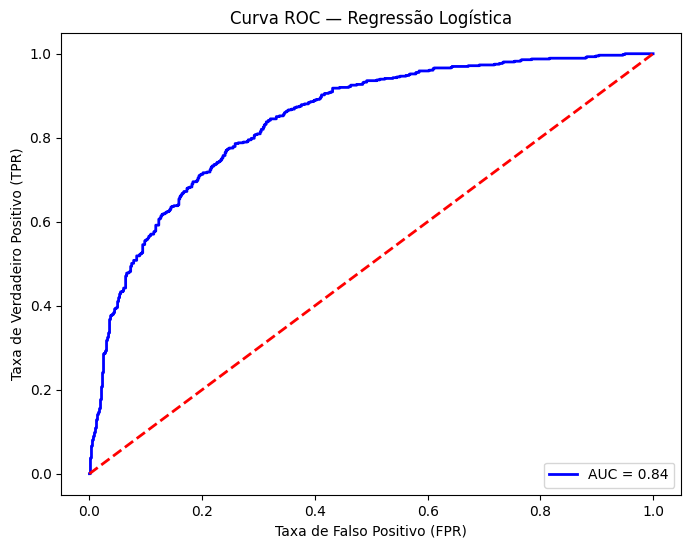

In [63]:
# Curva ROC com AUC (qualidade do modelo)

# Mostra o quão bem o modelo diferencia churn x não churn.
# Probabilidades do modelo
roc_auc_score(y_test, best_log_reg.predict_proba(X_test)[:,1])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--')
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo (TPR)")
plt.title("Curva ROC — Regressão Logística")
plt.legend(loc="lower right")
plt.show()


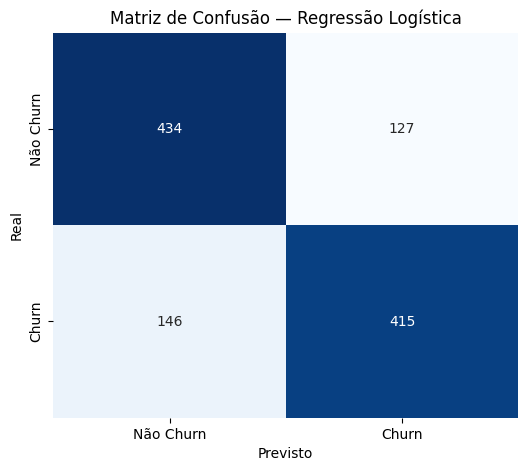

In [64]:
# Matriz de confusão (acertos e erros).
# Mostra quantos clientes o modelo acertou/errou na previsão.
# Matriz de confusão (acertos e erros).
y_pred = best_log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Não Churn", "Churn"],
            yticklabels=["Não Churn", "Churn"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — Regressão Logística")
plt.show()


/tmp/ipython-input-449114904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coeficiente", y="Variável", palette="coolwarm")


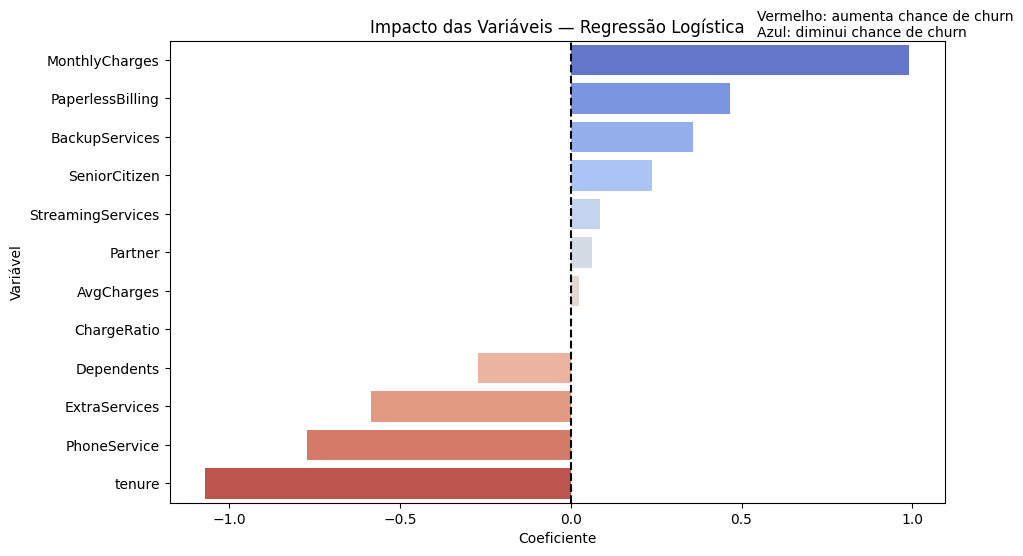

In [65]:
# Impacto das variáveis na regressão logística
# Importância das Variáveis (Coeficientes da Regressão Logística)

coef_df = pd.DataFrame({
    "Variável": X_train.columns,
    "Coeficiente": best_log_reg.coef_[0]  # <- usando o modelo treinado
}).sort_values(by="Coeficiente", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x="Coeficiente", y="Variável", palette="coolwarm")
plt.title("Impacto das Variáveis — Regressão Logística")
plt.axvline(0, color="black", linestyle="--")

# Legenda explicativa no canto direito do gráfico
plt.text(x=coef_df['Coeficiente'].max()*0.55, y=-0.6,
         s="Vermelho: aumenta chance de churn\nAzul: diminui chance de churn",
         fontsize=10, color='black')

plt.xlabel("Coeficiente")
plt.ylabel("Variável")
plt.show()


# ***************************************************************************
# Anexos abaixo: Códigos extras testados mas não úteis para o projeto acima.
# ***************************************************************************

# ************************************************************************
# # Depois de avaliar e ver que não houve nenhuma melhora signficativa com os hiperparametros ajustados, vale a pena tentar melhorar os outros modelos.
# # ***** Mesmo com os ajustes Regressão Lógistica continuou sendo a melhor opção.*****
# *************************************************************************
```

# # árvore de decisão - testar novos parametros
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(random_state=42)

# param_grid_dt = {
#     'criterion': ['gini', 'entropy', 'log_loss'],
#     'max_depth': [None, 5, 10, 20, 30],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 5, 10]
# }

# grid_search_dt = GridSearchCV(
#     estimator=dt,
#     param_grid=param_grid_dt,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=2
# )

# grid_search_dt.fit(X_train, y_train)

# print("Melhores parâmetros (DecisionTree):", grid_search_dt.best_params_)
# print("Melhor score:", grid_search_dt.best_score_)

# best_dt = grid_search_dt.best_estimator_
```

```
# # random forest - Testar novos parametros
# from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(random_state=42)

# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# grid_search_rf = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid_rf,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=2
# )

# grid_search_rf.fit(X_train, y_train)

# print("Melhores parâmetros (RandomForest):", grid_search_rf.best_params_)
# print("Melhor score:", grid_search_rf.best_score_)

# best_rf = grid_search_rf.best_estimator_
```

```
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# def avaliar_modelo(model, X_test, y_test, nome="Modelo"):
#     y_pred = model.predict(X_test)
#     accuracy  = accuracy_score(y_test, y_pred)
#     precision = precision_score(y_test, y_pred)
#     recall    = recall_score(y_test, y_pred)
#     f1        = f1_score(y_test, y_pred)

#     print(f"Modelo: {nome}")
#     print("Accuracy :", round(accuracy, 4))
#     print("Precision:", round(precision, 4))
#     print("Recall   :", round(recall, 4))
#     print("F1-Score :", round(f1, 4))
#     print("\nConfusion Matrix:")
#     print(confusion_matrix(y_test, y_pred))
#     print("\nClassification Report:")
#     print(classification_report(y_test, y_pred))
#     print("-"*50)

# # Avaliar modelos ajustados
# avaliar_modelo(best_dt, X_test, y_test, "DecisionTree (Ajustado)")
# avaliar_modelo(best_rf, X_test, y_test, "RandomForest (Ajustado)")
```

# ***************************************************************
# Gostei mais de outro gráfico, mas é uma ideia boa para futuros projetos
# ***************************************************************
```
# # Modelo simples só com MonthlyCharges
# log_reg_simple = LogisticRegression()
# log_reg_simple.fit(df[['MonthlyCharges']], df['Churn'])

# # Gera valores para MonthlyCharges
# X_plot = np.linspace(df['MonthlyCharges'].min(), df['MonthlyCharges'].max(), 500).reshape(-1, 1)

# # Predições
# y_prob_simple = log_reg_simple.predict_proba(X_plot)[:, 1]
# y_prob_full = log_reg_simple.predict_proba(
#     pd.DataFrame({'MonthlyCharges': X_plot.ravel()})
# )[:, 1]

# # Gráfico
# plt.figure(figsize=(8,6))
# plt.scatter(df['MonthlyCharges'], df['Churn'], alpha=0.3, label="Dados reais")
# plt.plot(X_plot, y_prob_simple, color="red", linewidth=2, label="Modelo Simples")
# plt.plot(X_plot, y_prob_full, color="blue", linewidth=2, label="Modelo Completo")
# plt.xlabel("Cobrança Mensal (MonthlyCharges)")
# plt.ylabel("Probabilidade de Churn")
# plt.title("Curva S — Comparação entre modelos")
# plt.legend()
# plt.show()

```



# Obs. Pq não usou esse código: Teria que cria a o dicionário para percorrer e ver se os valores são invalidos ou não, essa seria uma verificação completa
```
# Verificar valores invalidos
def verificar_valores_invalidos(df):
    invalidos = {}
    total_invalidos = 0
    
    for col in df.columns:
        if df[col].dtype.name == 'category' or df[col].dtype == object:
            # Apenas mostramos valores únicos, não há "inválidos" sem referência
            valores_unicos = df[col].dropna().unique()
            invalidos[col] = {'valores': valores_unicos, 'quantidade': len(df[col])}
        elif np.issubdtype(df[col].dtype, np.number):
            # Valores que não são numéricos
            mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
            qtd = mask.sum()
            if qtd > 0:
                invalidos[col] = {'valores': df[col][mask].unique(), 'quantidade': qtd}
                total_invalidos += qtd
    
    if invalidos:
        print(f"Total de valores inválidos no dataset: {total_invalidos}\n")
        for col, info in invalidos.items():
            print(f"Coluna '{col}' possui {info['quantidade']} valor(es) inválido(s): {info['valores']}")
    else:
        print("Nenhum valor inválido encontrado!")

verificar_valores_invalidos(df)
```
